In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")

pd.set_option( 'display.max_columns' , None )
df = pd.read_csv(r'C:\Users\Samak\OneDrive\เดสก์ท็อป\Fraud Detection\Data\fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [4]:
df.isna().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

# EDA

### Fraud Rate by Features

In [7]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='str')

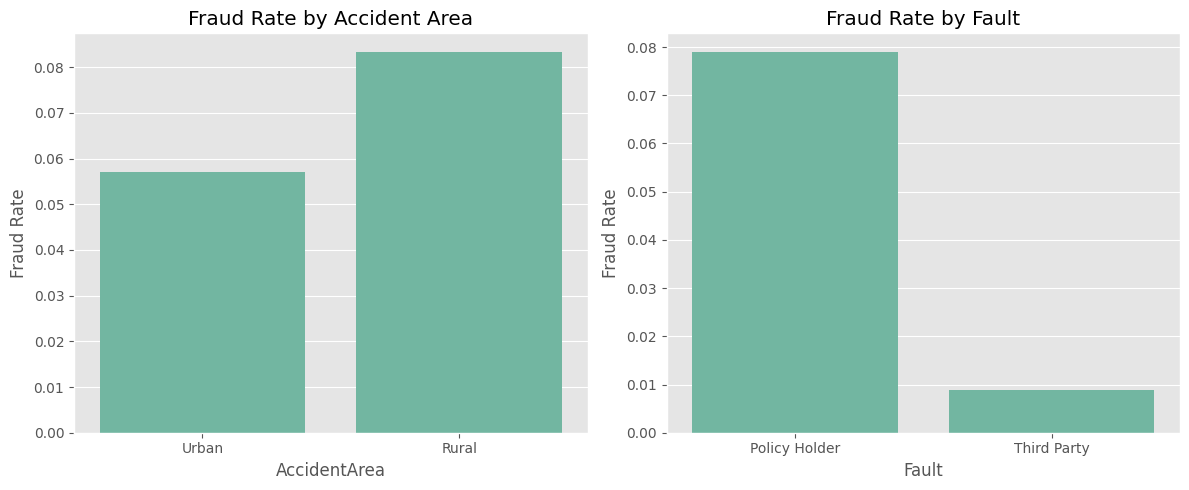

In [8]:
#Fraud Rate by Accident Area and Fault
# 1. Fraud Rate by AccidentArea and Fault
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='AccidentArea', y='FraudFound_P', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Fraud Rate by Accident Area')
axes[0].set_ylabel('Fraud Rate')

sns.barplot(x='Fault', y='FraudFound_P', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Fraud Rate by Fault')
axes[1].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

- Accident Area: อัตราการเกิด Fraud ในพื้นที่ชนบท (Rural) อยู่ที่ประมาณ 8.32% ซึ่งสูงกว่าพื้นที่เขตเมือง (Urban) ที่มีอัตรา 5.72% อย่างชัดเจน

- Fault: เมื่อผู้เอาประกัน (Policy Holder) เป็นฝ่ายผิด อัตราการพบ Fraud จะสูงปรี๊ดถึง 7.89% ในขณะที่ถ้าบุคคลที่สาม (Third Party) เป็นฝ่ายผิด อัตรา Fraud จะต่ำมากเพียง 0.88%

### Fraud Rate by VehicleCategory and BasePolicy

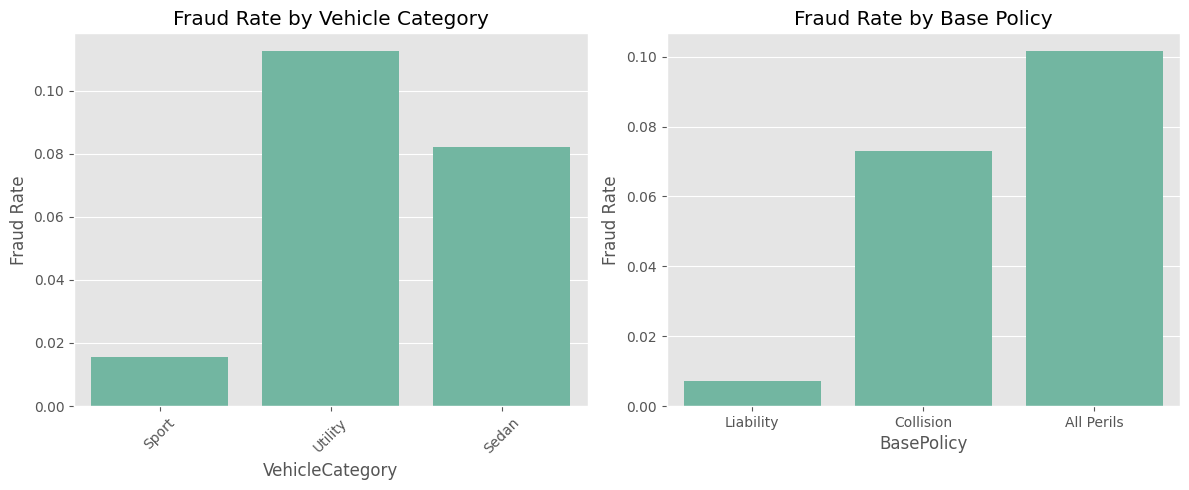

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='VehicleCategory', y='FraudFound_P', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Fraud Rate by Vehicle Category')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='BasePolicy', y='FraudFound_P', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Fraud Rate by Base Policy')
axes[1].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

- Vehicle Category: รถอเนกประสงค์ (Utility) มีสัดส่วนการทำ Fraud สูงสุดถึง 11.25% ตามมาด้วยรถเก๋ง (Sedan) 8.22% ส่วนรถสปอร์ต (Sport) แทบไม่มีการ Fraud เลย (1.57%)

- Base Policy: กรมธรรม์ประเภท All Perils (ประกันภัยครอบคลุมทุกความเสี่ยง) มีการ Fraud สูงสุดที่ 10.16% รองลงมาคือ Collision (ชนแบบมีคู่กรณี) 7.3% ส่วน Liability (ความรับผิดต่อบุคคลภายนอก) มี Fraud น้อยมากเพียง 0.7%

### Fraud Rate By Month

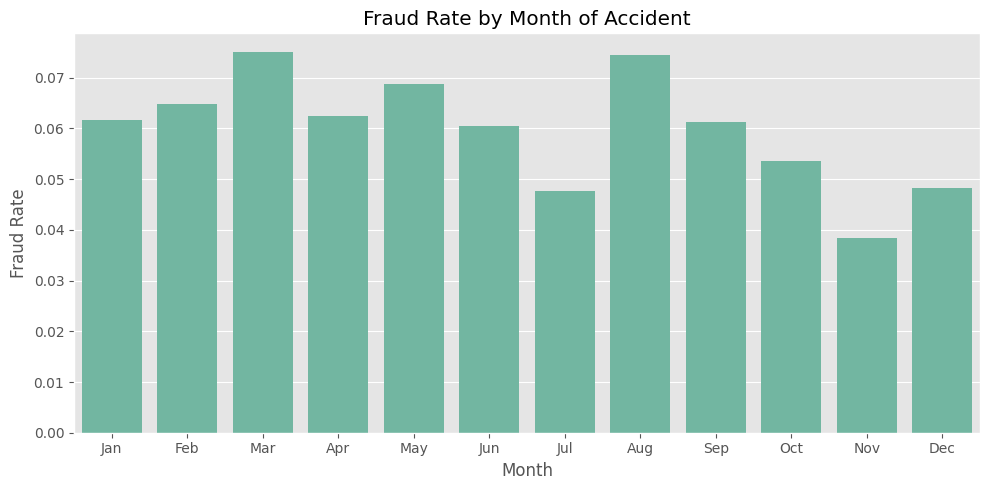

In [10]:
plt.figure(figsize=(10, 5))
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.barplot(x='Month', y='FraudFound_P', data=df, order=months_order, errorbar=None)
plt.title('Fraud Rate by Month of Accident')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

- อัตราการเกิด Fraud มีความผันผวนไปตามเดือน โดยเดือน มีนาคม (Mar) และ สิงหาคม (Aug) มีอัตราการเกิด Fraud สูงสุด (ประมาณ 7.5%)

- ในขณะที่ช่วงปลายปีอย่างเดือน พฤศจิกายน (Nov) มีอัตราต่ำที่สุด (3.8%)

Insight: อาจมีความเชื่อมโยงกับฤดูกาล หรือช่วงเวลาที่คนต้องการเงินก้อน (เช่น ก่อนเปิดเทอม หรือหลังเทศกาล) แม้ปัจจัยเรื่องเดือนอาจจะไม่ได้เป็นปัจจัยหลักเทียบเท่าประเภทรถหรือแผนประกัน

### Age vs Fraud

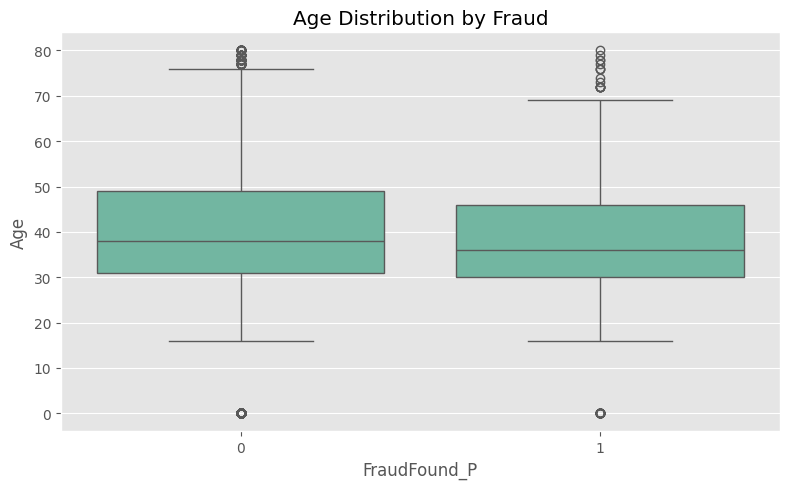

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='FraudFound_P', y='Age', data=df)
plt.title('Age Distribution by Fraud')
plt.tight_layout()
plt.show()

- Age Distribution: อายุเฉลี่ยของกลุ่มที่ทำ Fraud (38 ปี) จะน้อยกว่ากลุ่มปกติเล็กน้อย (40 ปี)

- Data Anomaly (ความผิดปกติของข้อมูล): จากการสำรวจลึกลงไป พบว่ามีข้อมูลที่ระบุว่า อายุ = 0 ปี จำนวนถึง 320 รายการ ซึ่งที่น่าตกใจคือ กลุ่มที่ไม่ได้ระบุอายุนี้ มีอัตราการเกิด Fraud สูงเกือบ 9.7% (สูงกว่าค่าเฉลี่ยรวมของ Fraud ที่ 6%)

### Fraud Rate by Make (Car Brand)

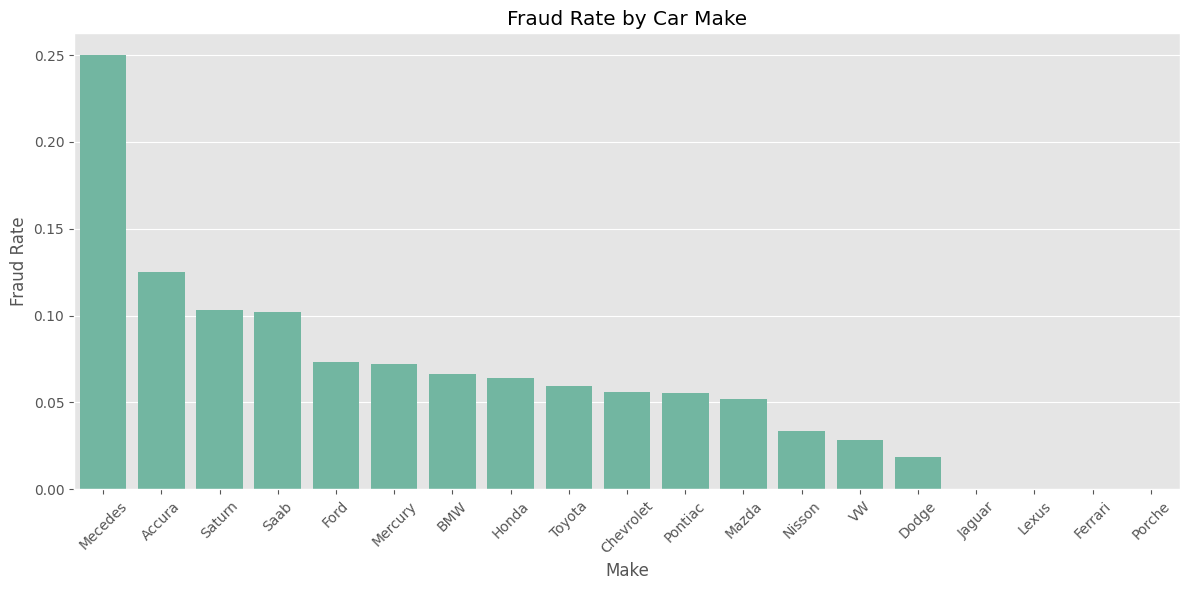

In [12]:
plt.figure(figsize=(12, 6))
make_order = df.groupby('Make')['FraudFound_P'].mean().sort_values(ascending=False).index


sns.barplot(x='Make', y='FraudFound_P', data=df, order=make_order, errorbar=None)
plt.title('Fraud Rate by Car Make')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- ยี่ห้อ Accura (Acura) น่าจับตามองมากที่สุด เพราะมีเคสการเคลมถึง 472 เคส และมีอัตรา Fraud สูงถึง 12.5% (สูงกว่าค่าเฉลี่ยที่ 6% ถึงสองเท่า)

- ส่วนรถแบรนด์ตลาดอย่าง Honda, Toyota, Chevrolet มีอัตรา Fraud อยู่ในระดับเฉลี่ยปกติ (ประมาณ 5-6%)

- Mercedes มีอัตรา Fraud 25% ก็จริง แต่มีข้อมูลแค่ 4 เคส จึงอาจยังใช้อ้างอิงไม่ได้มากนัก)

### Fraud Rate by Past Number of Claims and VehiclePrice

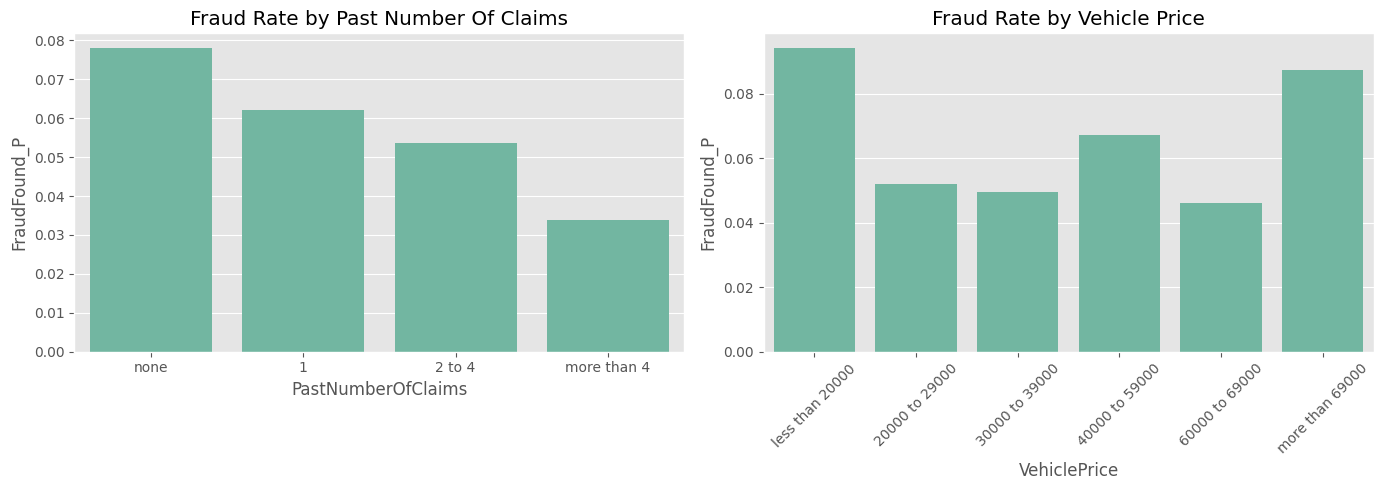

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
claim_order = ['none', '1', '2 to 4', 'more than 4']
sns.barplot(x='PastNumberOfClaims', y='FraudFound_P', data=df, order=claim_order, ax=axes[0], errorbar=None)
axes[0].set_title('Fraud Rate by Past Number Of Claims')

price_order = ['less than 20000', '20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000', 'more than 69000']
sns.barplot(x='VehiclePrice', y='FraudFound_P', data=df, order=price_order, ax=axes[1], errorbar=None)
axes[1].set_title('Fraud Rate by Vehicle Price')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

- คนที่ "ไม่เคยมีประวัติการเคลมเลย (none)" มีอัตราการเกิด Fraud สูงที่สุด (7.8%)

- ในทางกลับกัน คนที่มีประวัติการเคลมบ่อยๆ (more than 4 ครั้ง) กลับมีอัตรา Fraud ต่ำสุด (3.4%)

- เหตุผลที่เป็นไปได้: มิจฉาชีพอาจจะใช้ "ประวัติขาวสะอาด" (Clean Slate) เพื่อให้บริษัทประกันตายใจและอนุมัติกรมธรรม์ง่ายขึ้น หรืออีกมุมหนึ่งอาจจะเป็นบัญชีที่เพิ่งเปิดมาเพื่อตั้งใจทำ Fraud โดยเฉพาะ

### - อัตรา Fraud กระจุกตัวอยู่ที่สองขั้วของราคารถ คือ:

- กลุ่มรถราคาถูกมาก (น้อยกว่า 20,000) มี Fraud 9.4%

- กลุ่มรถราคาแพงมาก (มากกว่า 69,000) มี Fraud 8.7%

### - ส่วนรถยนต์กลุ่มราคากลางๆ (20,000 - 39,000) จะเกิด Fraud ต่ำกว่า (ประมาณ 5%)

### Fraud Rate by PoliceReportFiled & WitnessPresent

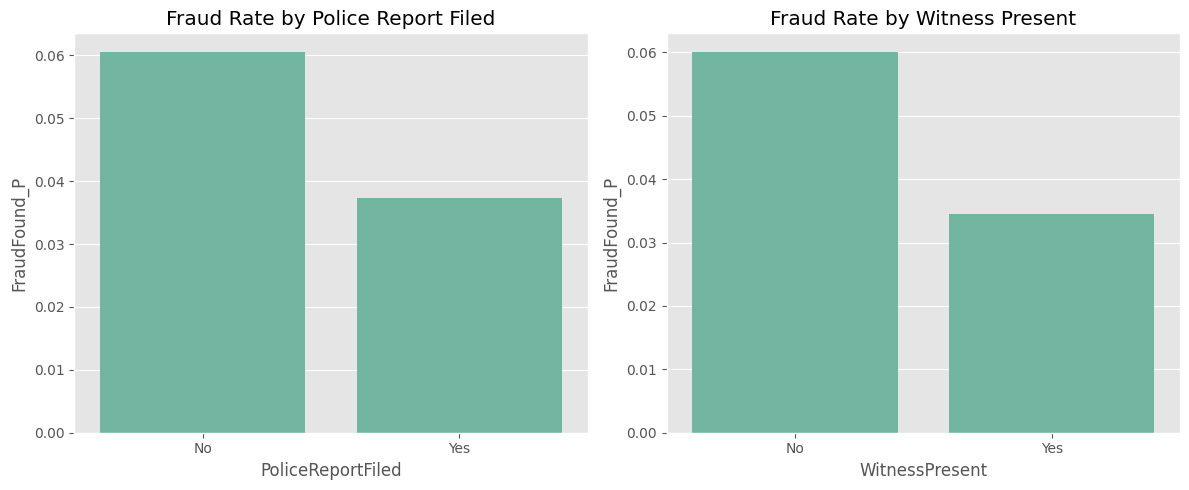

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='PoliceReportFiled', y='FraudFound_P', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Fraud Rate by Police Report Filed')

sns.barplot(x='WitnessPresent', y='FraudFound_P', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Fraud Rate by Witness Present')
plt.tight_layout()
plt.show()

- การทำ Fraud ส่วนใหญ่ "ไม่มีพยาน (No Witness)" (6%) และ "ไม่มีการแจ้งความกับตำรวจ (No Police Report)" (6%)

- เคสที่มีพยานหรือมีใบแจ้งความ ตำรวจลงพื้นที่ อัตราการเกิด Fraud จะลดลงเหลือแค่ราวๆ 3.4 - 3.7% เท่านั้น

- เหตุผลที่เป็นไปได้: มิจฉาชีพพยายามหลีกเลี่ยงการให้เจ้าหน้าที่รัฐเข้ามาตรวจสอบ หรือหลีกเลี่ยงสถานการณ์ที่มีบุคคลที่สามเห็นเหตุการณ์ เพื่อให้สามารถเล่าเรื่องเท็จได้ง่ายขึ้น

### Fraud Rate by Sex and MaritalStatus

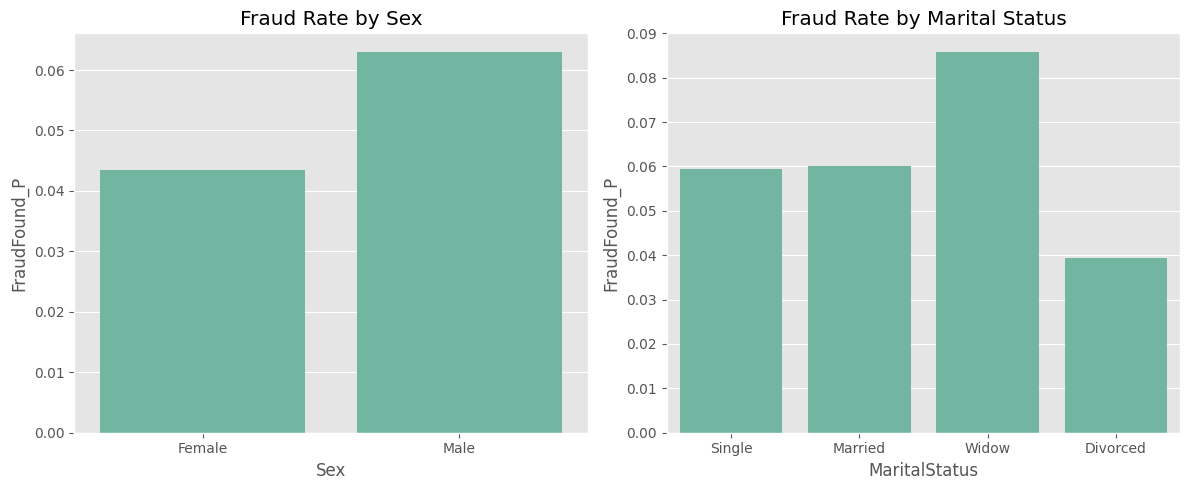

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Sex', y='FraudFound_P', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Fraud Rate by Sex')

sns.barplot(x='MaritalStatus', y='FraudFound_P', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Fraud Rate by Marital Status')
plt.tight_layout()
plt.show()

- เพศชาย (Male) มีสัดส่วนการเคลมรวมสูงกว่าเพศหญิงมาก (ชาย 13,000 เคส vs หญิง 2,420 เคส)

- อัตราการเกิด Fraud: เพศชายมีอัตราการเกิด Fraud อยู่ที่ 6.29% ซึ่งสูงกว่าเพศหญิงที่อยู่ที่ 4.34% * สรุป Insight: ผู้ชายมีแนวโน้มที่จะมีส่วนร่วมในการทำเคลมประกันเท็จมากกว่าผู้หญิงอย่างเห็นได้ชัดในชุดข้อมูลนี้

- กลุ่ม Married (แต่งงานแล้ว) และ Single (โสด) เป็นกลุ่มที่มีจำนวนการเคลมมากที่สุด (10,625 เคส และ 4,684 เคส ตามลำดับ) และทั้งสองกลุ่มนี้มีอัตราการเกิด Fraud ใกล้เคียงกันมาก อยู่ที่ประมาณ 5.9% - 6.0% (เกาะกลุ่มอยู่แถวๆ ค่าเฉลี่ยรวมของ Dataset)

- กลุ่ม Divorced (หย่าร้าง) มีอัตราการเกิด Fraud ต่ำที่สุด คือ 3.9% (จาก 76 เคส)

- กลุ่ม Widow (หม้าย) มีอัตราการเกิด Fraud สูงที่สุดถึง 8.57% แต่มีข้อสังเกตว่ากลุ่มนี้มีจำนวนข้อมูลน้อยมาก (เพียง 35 เคส พบการทุจริต 3 เคส)

- สรุป : สถานภาพสมรสแบบ "โสด" หรือ "แต่งงานแล้ว" ไม่ได้สร้างความแตกต่างในเรื่องการทำทุจริตอย่างมีนัยสำคัญ แต่เคสที่ผู้เคลมมีสถานะเป็น "หม้าย" อาจต้องมีการตรวจสอบที่ละเอียดขึ้นเล็กน้อยเนื่องจากสถิติชี้ให้เห็นสัดส่วน Fraud ที่สูงกว่าปกติ (แม้ข้อมูลจะยังมีจำนวนน้อยก็ตาม)

In [16]:
print("Fraud by Make:")
make_stats = df.groupby('Make')['FraudFound_P'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
print(make_stats.head(10))

print("\nFraud by Past Number of Claims:")
claim_order = ['none', '1', '2 to 4', 'more than 4']
claim_stats = df.groupby('PastNumberOfClaims')['FraudFound_P'].agg(['mean', 'count']).loc[claim_order]
print(claim_stats)

print("\nFraud by Witness Present:")
witness_stats = df.groupby('WitnessPresent')['FraudFound_P'].agg(['mean', 'count'])
print(witness_stats)

print("\nFraud by Police Report Filed:")
police_stats = df.groupby('PoliceReportFiled')['FraudFound_P'].agg(['mean', 'count'])
print(police_stats)

print("\nFraud by Vehicle Price:")
price_order = ['less than 20000', '20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000', 'more than 69000']
price_stats = df.groupby('VehiclePrice')['FraudFound_P'].agg(['mean', 'count']).loc[price_order]
print(price_stats)

print("\nFraud by Number of Cars involved:")
cars_stats = df.groupby('NumberOfCars')['FraudFound_P'].agg(['mean', 'count'])
print(cars_stats)

Fraud by Make:
               mean  count
Make                      
Mecedes    0.250000      4
Accura     0.125000    472
Saturn     0.103448     58
Saab       0.101852    108
Ford       0.073333    450
Mercury    0.072289     83
BMW        0.066667     15
Honda      0.063906   2801
Toyota     0.059596   3121
Chevrolet  0.055919   1681

Fraud by Past Number of Claims:
                        mean  count
PastNumberOfClaims                 
none                0.077895   4352
1                   0.062133   3573
2 to 4              0.053601   5485
more than 4         0.033831   2010

Fraud by Witness Present:
                    mean  count
WitnessPresent                 
No              0.060001  15333
Yes             0.034483     87

Fraud by Police Report Filed:
                       mean  count
PoliceReportFiled                 
No                 0.060499  14992
Yes                0.037383    428

Fraud by Vehicle Price:
                     mean  count
VehiclePrice                

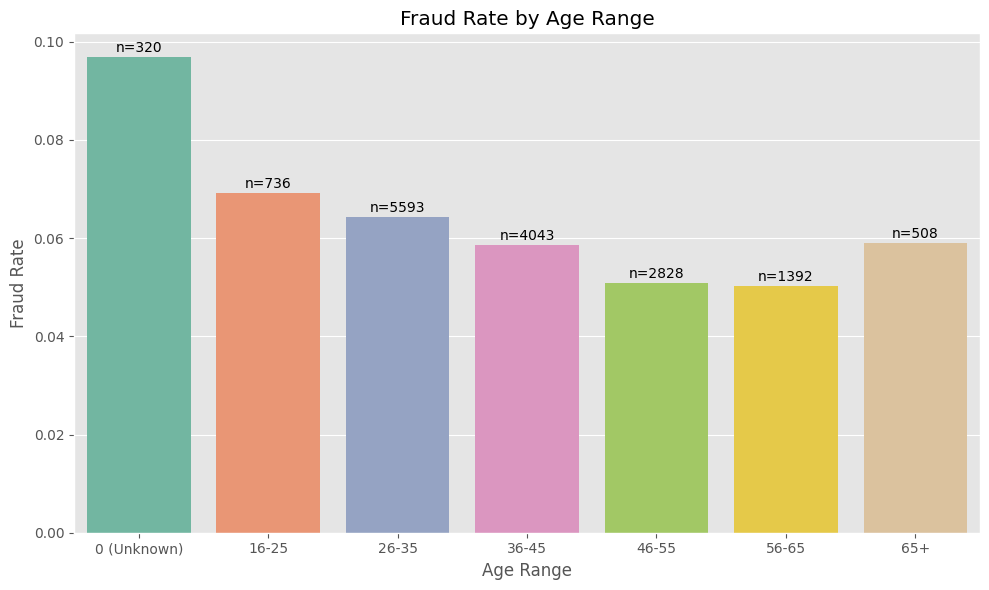

     Age_range  mean_percent  count
0  0 (Unknown)      9.687500    320
1        16-25      6.929348    736
2        26-35      6.436617   5593
3        36-45      5.861984   4043
4        46-55      5.091938   2828
5        56-65      5.028736   1392
6          65+      5.905512    508


In [17]:
bins = [-1, 0, 25, 35, 45, 55, 65, 120]
labels = ['0 (Unknown)', '16-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_range'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Calculate Fraud Rate by Age_range
age_range_stats = df.groupby('Age_range', observed=False)['FraudFound_P'].agg(['mean', 'count']).reset_index()
age_range_stats['mean_percent'] = age_range_stats['mean'] * 100

# Plotting
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
ax = sns.barplot(x='Age_range', y='mean', data=age_range_stats, palette='Set2')
plt.title('Fraud Rate by Age Range')
plt.ylabel('Fraud Rate')
plt.xlabel('Age Range')

# Add number of samples (n) on top of bars
for index, row in age_range_stats.iterrows():
    ax.text(index, row['mean'] + 0.001, f"n={row['count']}", color='black', ha="center", size=10)

plt.tight_layout()
plt.show()

print(age_range_stats[['Age_range', 'mean_percent', 'count']])

### กลุ่มที่มี Fraud Rate สูงที่สุดแบบก้าวกระโดด:

- กลุ่ม 0 (Unknown): มีอัตราการเกิด Fraud สูงถึง 9.7% (จาก 320 เคส)

### กลุ่มวัยรุ่นและวัยทำงานตอนต้น (มีความเสี่ยงรองลงมา):

- กลุ่ม 16 - 25 ปี: มี Fraud Rate 6.9% (จาก 736 เคส)

- กลุ่ม 26 - 35 ปี: มี Fraud Rate 6.4% (กลุ่มนี้มีจำนวนการเคลมสูงที่สุดคือเกือบ 5,600 เคส)

- Insight: คนอายุน้อย/เพิ่งเริ่มทำงาน มีแนวโน้มที่จะมีการทำเคลมเท็จมากกว่าวัยผู้ใหญ่ อาจเกี่ยวเนื่องกับภาระทางการเงิน ความคึกคะนอง หรือประสบการณ์การขับขี่

### กลุ่มวัยผู้ใหญ่ตอนกลางถึงตอนปลาย (ความเสี่ยงต่ำที่สุด):

- กลุ่ม 36 - 45 ปี: ลดลงมาเหลือ 5.9%

- กลุ่ม 46 - 55 ปี และ 56 - 65 ปี: อัตราทุจริตต่ำที่สุด อยู่ที่ระดับ 5.0% - 5.1%

- Insight: คนในวัยนี้มักมีวุฒิภาวะและความมั่นคงทางการเงินมากกว่า จึงมีสัดส่วนการเคลมเท็จที่น้อยที่สุด

### กลุ่มผู้สูงอายุ (ความเสี่ยงเริ่มกลับมาสูงขึ้นเล็กน้อย):

- กลุ่ม 65+ ปีขึ้นไป: อัตรา Fraud ดีดกลับขึ้นมาที่ 5.9% (จาก 508 เคส)

- Insight: แม้จะไม่สูงเท่าวัยรุ่น แต่ผู้สูงอายุบางคนอาจถูกมิจฉาชีพ (เช่น ลูกหลาน หรือบุคคลภายนอก) นำชื่อหรือรถไปใช้ในการทำประกัน/ทำเคลมเท็จ (Identity/Family member Fraud)

### Age distribution by Vehicle Category

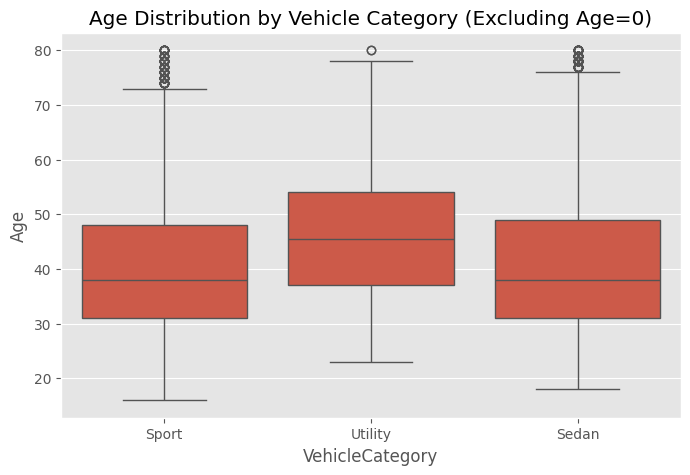

In [18]:
df_valid_age = df[df['Age'] > 0]

plt.figure(figsize=(8, 5))
sns.boxplot(x='VehicleCategory', y='Age', data=df_valid_age)
plt.title('Age Distribution by Vehicle Category (Excluding Age=0)')
plt.show()

### - ถ้าเราตัดคนที่ไม่ได้ระบุอายุ (Age = 0) ออกไป เพื่อดูอายุจริงตามสถิติ:

- รถเก๋ง (Sedan): อายุเฉลี่ย 40.6 ปี (อยู่ในช่วง 18 - 80 ปี) ครึ่งหนึ่งของคนขับกลุ่มนี้อายุประมาณ 38 ปี

- รถสปอร์ต (Sport): อายุเฉลี่ย 40.4 ปี (อยู่ในช่วง 16 - 80 ปี) อายุใกล้เคียงกับกลุ่มคนขับรถเก๋งมาก

- รถอเนกประสงค์ (Utility): อายุเฉลี่ย 46 ปี (อยู่ในช่วง 23 - 80 ปี) เป็นกลุ่มที่มีอายุเฉลี่ยสูงที่สุด ซึ่งสมเหตุสมผลเพราะส่วนใหญ่จะเป็นผู้ใหญ่วัยทำงานขึ้นไปที่มีกำลังซื้อรถอเนกประสงค์

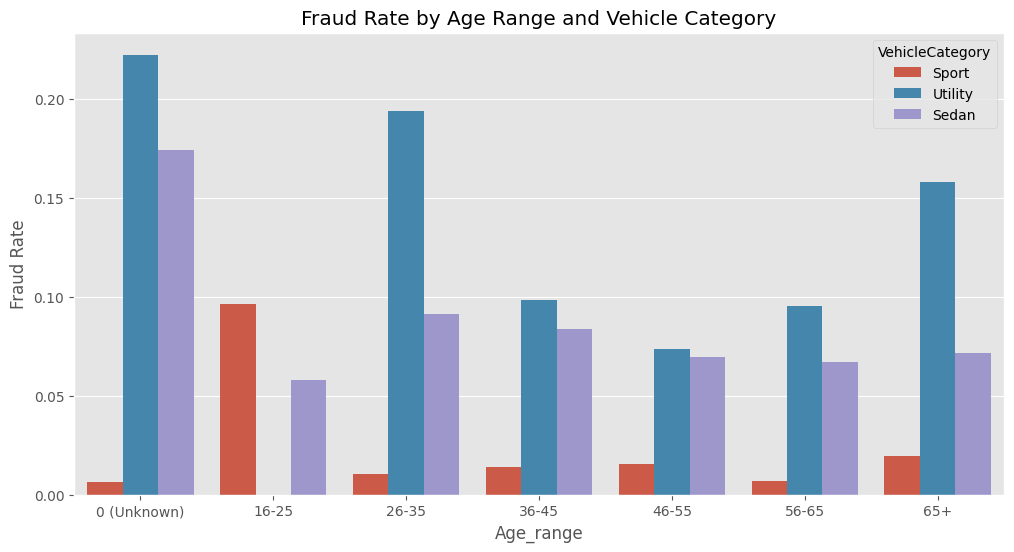

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Age_range', y='FraudFound_P', hue='VehicleCategory', data=df, errorbar=None)
plt.title('Fraud Rate by Age Range and Vehicle Category')
plt.ylabel('Fraud Rate')
plt.show()

## การเกิด Fraud เป็นอย่างไร เมื่อนำ "อายุ + ประเภทรถ" มาพิจารณา?

### Red Flag #1: รถอเนกประสงค์ (Utility) + คนอายุ 26-35 ปี (Fraud พุ่งสูงถึง 19.4%)

- ถึงแม้คนขับรถ Utility โดยเฉลี่ยจะอายุ 46 ปี แต่กลุ่มที่ทำทุจริตมากที่สุดกลับเป็นวัยทำงานตอนต้น (26-35 ปี) * นอกจากนี้ กลุ่มคนที่ Age = 0 (ไม่ระบุอายุ) ที่อ้างว่าขับรถ Utility มีอัตราทุจริตสูงทะลุถึง 22.2%! (แม้ข้อมูลจะมีแค่ 9 เคส แต่ก็น่าสงสัยมาก)

- ข้อสังเกต: กลุ่ม Utility แม้จะมีการเคลมน้อยในภาพรวม (รวมๆ เกือบๆ 400 เคส) แต่ถ้าเป็นวัย 26-35 ปีมาเคลม หรือไม่ระบุอายุมา ให้ตั้งธงสงสัยไว้ก่อนเลยครับว่าอาจจะมีทุจริต!

### Red Flag #2: รถเก๋ง (Sedan) + ไม่ระบุอายุ (Fraud สูงถึง 17.39%)

- ในกลุ่มรถเก๋ง (Sedan) ปกติแล้ว Fraud จะอยู่ที่ประมาณ 6-9%

- แต่ถ้าเป็นเคสที่ ไม่ระบุอายุ (Age = 0) อัตราการทุจริตจะกระโดดขึ้นไปที่ 17.39% ทันที (จาก 161 เคส) นี่คือความผิดปกติของข้อมูลที่บ่งบอกถึงการจงใจปกปิด

### Red Flag #3: รถสปอร์ต (Sport) + วัยรุ่น 16-25 ปี (Fraud สูงผิดปกติที่ 9.63%)

- ในภาพรวม รถสปอร์ตเป็นรถที่มีการทำทุจริต น้อยที่สุด แทบทุกช่วงอายุ (เฉลี่ยแค่ 1-2%)

- ถ้าคนขับเป็น วัยรุ่น (16-25 ปี) อัตราการทุจริตในกลุ่มนี้จะดีดตัวขึ้นมาเกือบ 10% เลยทีเดียว (จาก 218 เคส) ซึ่งอาจเป็นเพราะวัยรุ่นที่ขับรถสปอร์ตอาจเจตนาแต่งรถ หรือขับรถไปชนด้วยความคึกคะนอง แล้วพยายามทำเคลมเท็จเพื่อหลีกเลี่ยงความผิด

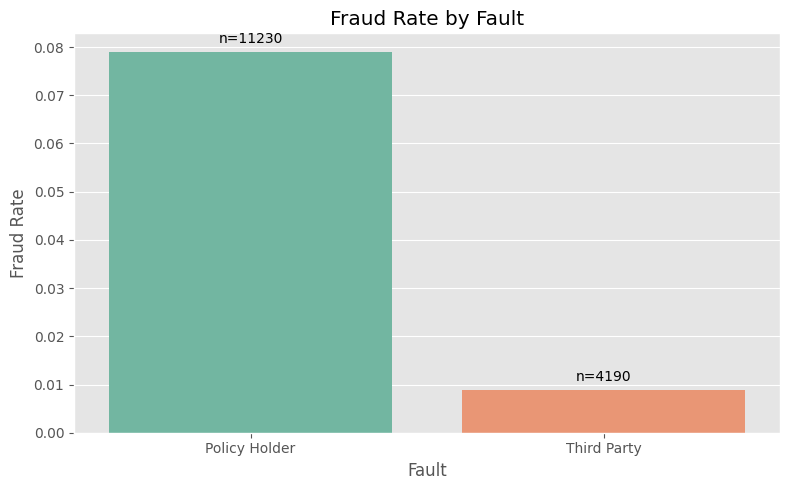

Fraud Rate by Fault:
                   mean  count
Fault                         
Policy Holder  0.078896  11230
Third Party    0.008831   4190


In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Fault', y='FraudFound_P', data=df, errorbar=None, palette='Set2')
plt.title('Fraud Rate by Fault')
plt.ylabel('Fraud Rate')
plt.xlabel('Fault')

# Add count labels on bars
fault_stats = df.groupby('Fault')['FraudFound_P'].agg(['mean', 'count'])
for index, (fault, row) in enumerate(fault_stats.iterrows()):
    plt.text(index, row['mean'] + 0.002, f"n={int(row['count'])}", 
             color='black', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Fraud Rate by Fault:")
print(fault_stats)

- ถ้าความผิดมากจากบุคคลภายนอก Fraud Rate จะต่ำมากๆ

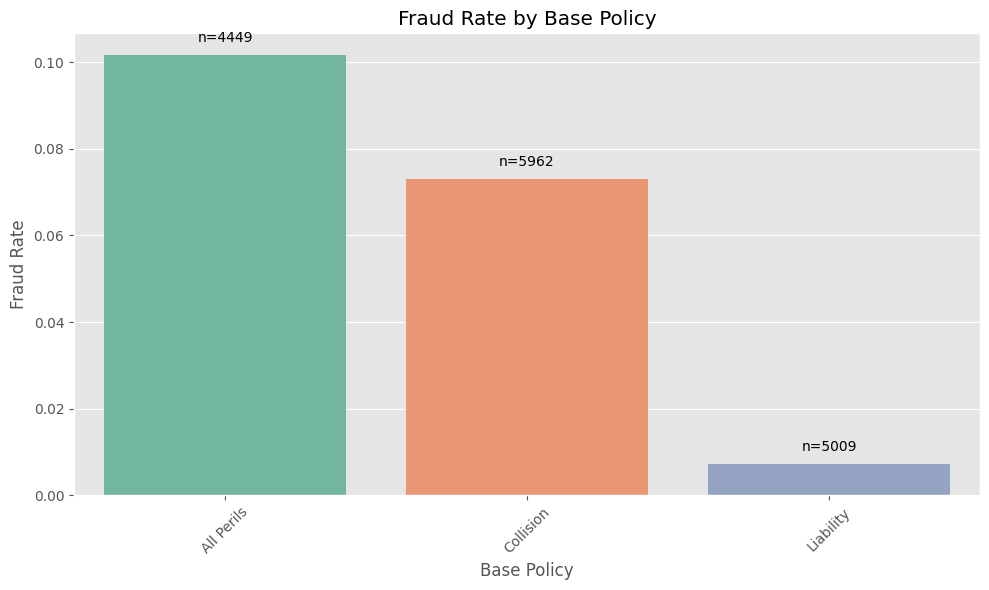

Fraud Rate by Base Policy:
                mean  count
BasePolicy                 
All Perils  0.101596   4449
Collision   0.072962   5962
Liability   0.007187   5009


In [24]:
# Fraud Rate by BasePolicy
fig, ax = plt.subplots(figsize=(10, 6))
basepolicy_stats = df.groupby('BasePolicy')['FraudFound_P'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

sns.barplot(x=basepolicy_stats.index, y='mean', data=basepolicy_stats.reset_index(), palette='Set2', ax=ax)
ax.set_title('Fraud Rate by Base Policy')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('Base Policy')

# Add count labels on bars
for index, (policy, row) in enumerate(basepolicy_stats.iterrows()):
    ax.text(index, row['mean'] + 0.003, f"n={int(row['count'])}", 
            color='black', ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Fraud Rate by Base Policy:")
print(basepolicy_stats)

- ตัว Liability มี Fraud Rate ต่ำมาก อาจจะเป็น Feature สำคัญต่อ Model